# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Examples on Exploratory Data Analysis** </center>
---
**Profesor**: Pablo Camarillo Ramirez

In [1]:
from spark_utils import SparkUtils

su = SparkUtils("spark://spark-master:7077", "Example EDA")
su._spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/10 00:49:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
!head data/movies/movies_dataset.csv

MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
1,Might toward capital,Comedy,2003,28-09-2003,China,6577427.79,6613685.82,15472035.66,1778530.85,3034053.32,6.2,58,7865,10596,Kristina Moore,Brian Mccormick
2,He however experience,Comedy,1988,14-02-1988,USA,1883810.1,1930949.15,3637731.12,247115.74,831828.84,5.2,44,1708,220,Benjamin Hudson,Ashley Pena
3,Star responsibility politics,Comedy,1971,02-11-1971,USA,2468079.29,4186694.69,7165111.24,878453.95,2171405.93,5.5,55,4678,7805,Kayla Young,Alexander Haley
4,Exactly live,Comedy,1998,06-08-1998,USA,1447311.46,2023683.92,4373820.26,570657.72,898886.01,7.3,87,2467,1751,Michael Ross,Patrick Barnett
5,Focus improve especially,Documentary,2021,17-12-2021,India,900915.86,2129629.1,3113017.38,361189.37,861775.91,6.1,67,5555,697,Faith Franklin,Duane Fletcher DDS
6,Deal reveal fine,Drama,

In [4]:
# MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,BudgetUSD,US_BoxOfficeUSD,Global_BoxOfficeUSD,Opening_Day_SalesUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,NumVotesIMDb,NumVotesRT,Director,LeadActor
movies_columns = [("MovieID", "int"),
                  ("Title", "string"),
                  ("Genre", "string"),
                  ("ReleaseYear", "int"),
                  ("ReleaseDate_Str", "string"),
                  ("Country", "string"),
                  ("BudgetUSD", "float"),
                  ("US_BoxOfficeUSD", "float"),
                  ("Global_BoxOfficeUSD", "float"),
                  ("Opening_Day_SalesUSD", "float"),
                  ("One_Week_SalesUSD", "float"),
                  ("IMDbRating", "float"),
                  ("RottenTomatoesScore", "float"),
                  ("NumVotesIMDb", "int"),
                  ("NumVotesRT", "int"),
                  ("Director", "string"),
                  ("LeadActor", "string")]

movies_schema = SparkUtils.generate_schema(movies_columns)

movies_date_str_df = (su._spark.read 
                .option("header", "true")
                .schema(movies_schema)
                .csv("/opt/spark/work-dir/data/movies/movies_dataset.csv"))

In [5]:
null_count_df = SparkUtils.null_count(movies_date_str_df)
null_count_df.show()

+-------+-----+-----+-----------+---------------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+--------+---------+
|MovieID|Title|Genre|ReleaseYear|ReleaseDate_Str|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|Director|LeadActor|
+-------+-----+-----+-----------+---------------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+--------+---------+
|      0|    0|    0|          0|              0|      0|        0|              0|                  0|                   0|                0|         0|                  0|           0|         0|       0|        0|
+-------+-----+-----+-----------+---------------+-------+---------+---------------+-------------------+--------------------+--------

In [6]:
from pyspark.sql.functions import to_date
movies_df = movies_date_str_df.withColumn("ReleaseDate", to_date("ReleaseDate_Str", "dd-MM-yyyy")).drop("ReleaseDate_Str")
movies_df.show(5)

+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|MovieID|               Title|      Genre|ReleaseYear|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|       Director|         LeadActor|ReleaseDate|
+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|      1|Might toward capital|     Comedy|       2003|  China|6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596| Kristina Moore|   Brian Mccormick| 2003-09-28|


In [7]:
movies_df.printSchema()

root
 |-- MovieID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genre: string (nullable = true)
 |-- ReleaseYear: integer (nullable = true)
 |-- Country: string (nullable = true)
 |-- BudgetUSD: float (nullable = true)
 |-- US_BoxOfficeUSD: float (nullable = true)
 |-- Global_BoxOfficeUSD: float (nullable = true)
 |-- Opening_Day_SalesUSD: float (nullable = true)
 |-- One_Week_SalesUSD: float (nullable = true)
 |-- IMDbRating: float (nullable = true)
 |-- RottenTomatoesScore: float (nullable = true)
 |-- NumVotesIMDb: integer (nullable = true)
 |-- NumVotesRT: integer (nullable = true)
 |-- Director: string (nullable = true)
 |-- LeadActor: string (nullable = true)
 |-- ReleaseDate: date (nullable = true)



In [8]:
!pip install matplotlib
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 12.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 17.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 12.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 KB 13.4 MB/s eta 0:00:0000:01


In [9]:
import matplotlib.pyplot as plt

# Line Charts
## Movies produced per year

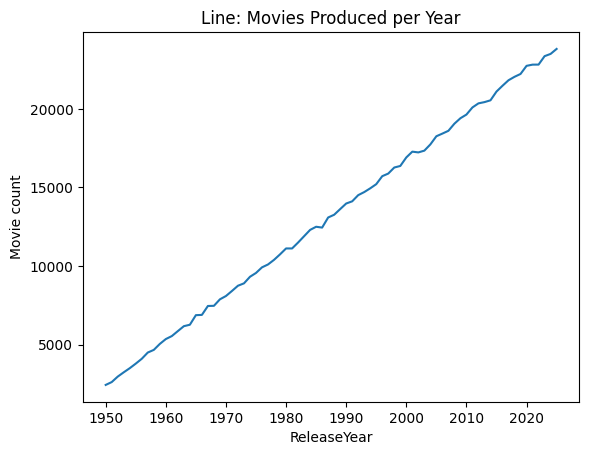

In [10]:
sdf = (movies_df
       .groupBy("ReleaseYear")
       .count()
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.plot(pdf["ReleaseYear"], pdf["count"])
plt.title("Line: Movies Produced per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Movie count")
plt.show()

## Average global revenue per year

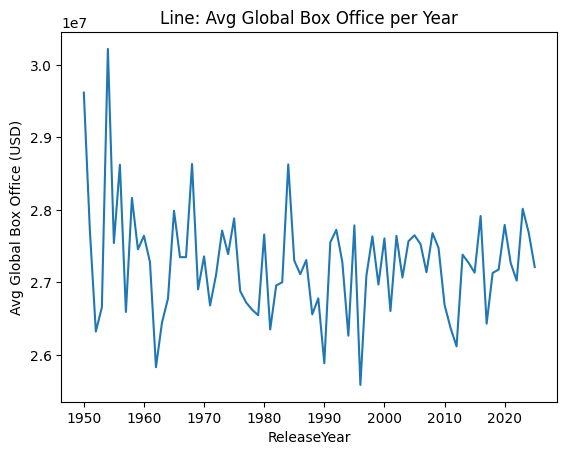

In [ ]:
import pyspark.sql.functions as F

sdf = (movies_df
       .groupBy("ReleaseYear")
       .agg(F.avg("Global_BoxOfficeUSD").alias("avg_global"))
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.plot(pdf["ReleaseYear"], pdf["avg_global"])
plt.title("Line: Avg Global Box Office per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Avg Global Box Office (USD)")
plt.show()

# Area Charts
## Total global revenue per year (area)

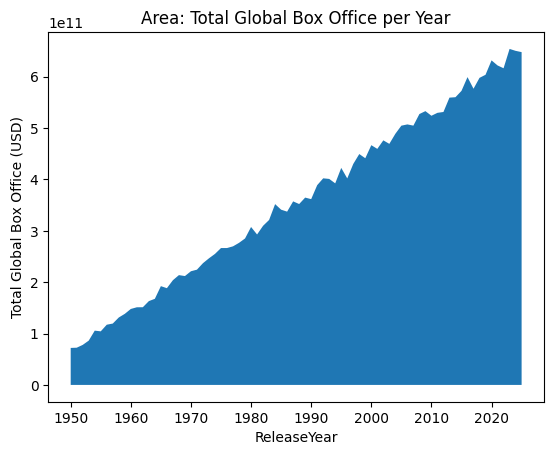

In [16]:
sdf = (movies_df
       .groupBy("ReleaseYear")
       .agg(F.sum("Global_BoxOfficeUSD").alias("sum_global"))
       .orderBy("ReleaseYear"))

pdf = sdf.toPandas()

plt.figure()
plt.fill_between(pdf["ReleaseYear"], pdf["sum_global"])
plt.title("Area: Total Global Box Office per Year")
plt.xlabel("ReleaseYear")
plt.ylabel("Total Global Box Office (USD)")
plt.show()

## Stacked-ish area by Genre (top genres)

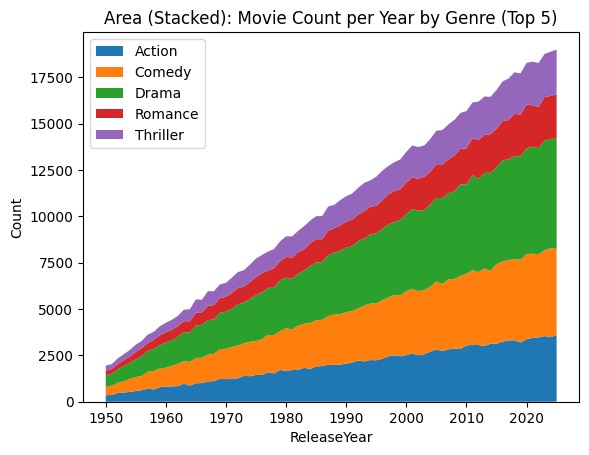

In [17]:
# pick top 5 genres by count
top_genres = [r["Genre"] for r in (movies_df.groupBy("Genre").count()
                                  .orderBy(F.col("count"), ascending=False)
                                  .limit(5).collect())]

sdf = (movies_df.where(F.col("Genre").isin(top_genres))
       .groupBy("ReleaseYear", "Genre")
       .count()
       .orderBy("ReleaseYear", "Genre"))

pdf = sdf.toPandas()

# pivot in pandas for plotting
pvt = pdf.pivot(index="ReleaseYear", columns="Genre", values="count").fillna(0).sort_index()

plt.figure()
plt.stackplot(pvt.index, *[pvt[c].values for c in pvt.columns], labels=pvt.columns)
plt.title("Area (Stacked): Movie Count per Year by Genre (Top 5)")
plt.xlabel("ReleaseYear")
plt.ylabel("Count")
plt.legend(loc="upper left")
plt.show()

# Bar & Column Charts
## Top genres by Genre count (bar)

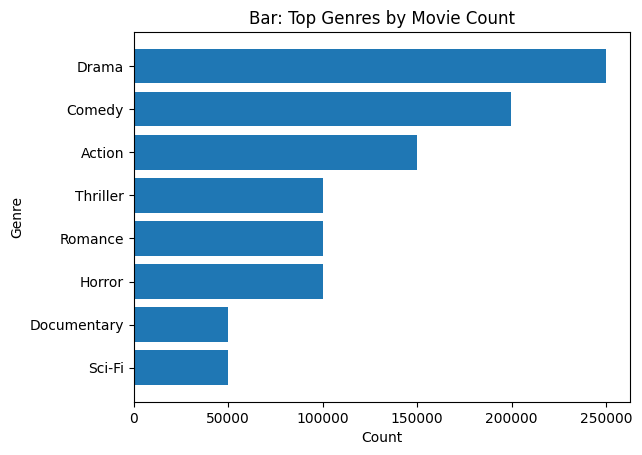

In [18]:

sdf = (movies_df.groupBy("Genre")
       .count()
       .orderBy(F.col("count"), ascending=False)
       .limit(10))

pdf = sdf.toPandas()

plt.figure()
plt.barh(pdf["Genre"], pdf["count"])
plt.title("Bar: Top Genres by Movie Count")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.show()

## Average IMDb rating by country (top 10 by count)

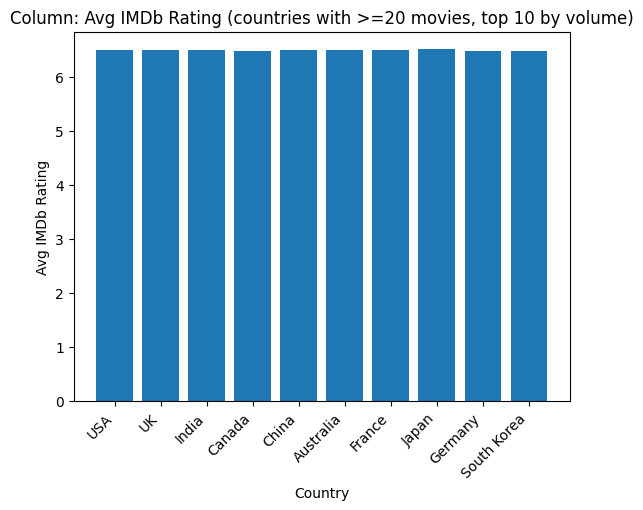

In [19]:
sdf = (movies_df.groupBy("Country")
       .agg(F.count("*").alias("freq"),
            F.avg("IMDbRating").alias("avg_imdb"))
       .where(F.col("freq") >= 20)
       .orderBy(F.col("freq"), ascending=False)
       .limit(10))

pdf = sdf.toPandas()

plt.figure()
plt.bar(pdf["Country"], pdf["avg_imdb"])
plt.title("Column: Avg IMDb Rating (countries with >=20 movies, top 10 by volume)")
plt.xlabel("Country")
plt.ylabel("Avg IMDb Rating")
plt.xticks(rotation=45, ha="right")
plt.show()

# Pie & Donut Charts
## Pie: share of top genres (+ Other)

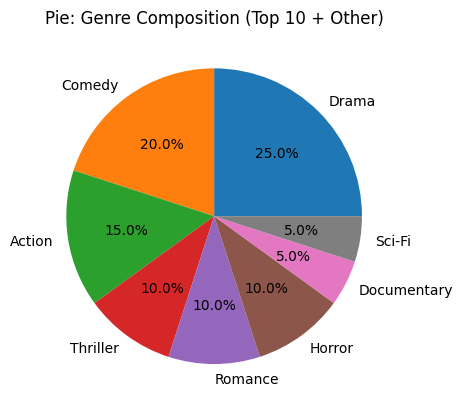

In [20]:
N = 10
counts = movies_df.groupBy("Genre").count().orderBy(F.col("count"), ascending=False)
top = counts.limit(N).toPandas()

total = counts.agg(F.sum("count").alias("total")).collect()[0]["total"]
top_sum = int(top["count"].sum())
other = int(total - top_sum)

labels = list(top["Genre"]) + (["Other"] if other > 0 else [])
sizes  = list(top["count"]) + ([other] if other > 0 else [])

plt.figure()
plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Pie: Genre Composition (Top 10 + Other)")
plt.show()

## Donut: same data

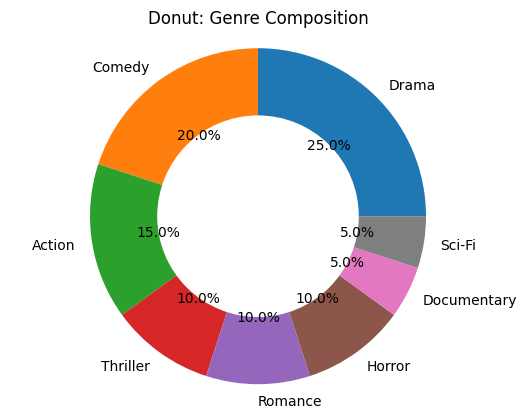

In [21]:
plt.figure()
plt.pie(sizes, labels=labels, autopct="%1.1f%%")
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Donut: Genre Composition")
plt.axis("equal")
plt.show()

## Question 1: Which genres dominate the dataset?

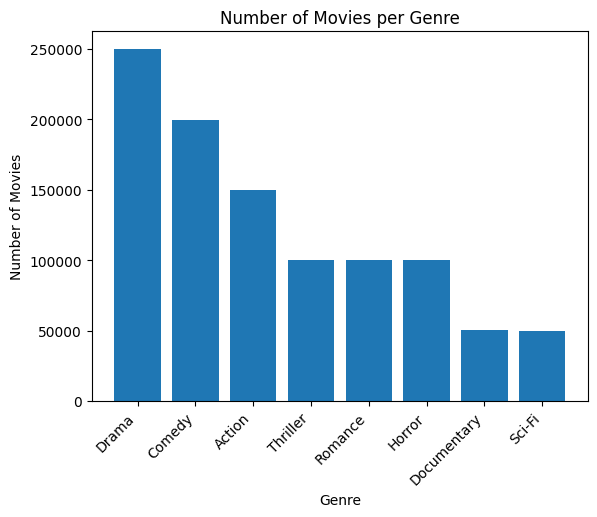

In [62]:
sdf = (movies_df.groupBy("Genre")
    .count()
    .orderBy(F.col("count"), ascending=False))

pdf = sdf.toPandas()

plt.figure()
plt.bar(pdf["Genre"], pdf["count"])
plt.title("Number of Movies per Genre")
plt.ylabel("Number of Movies")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha="right")
plt.show()

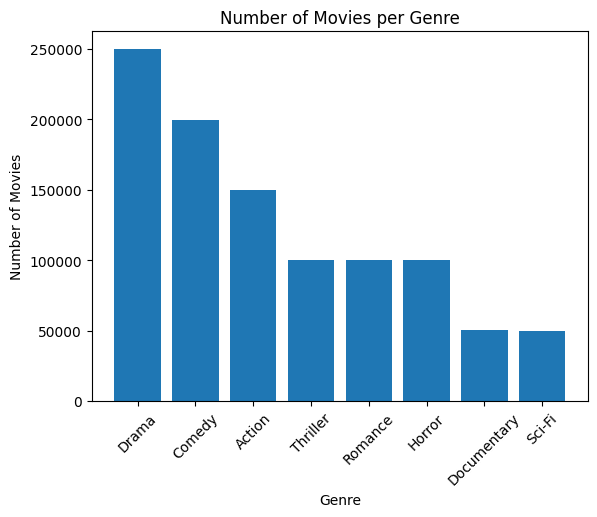

## Question 2: Which countries produce the most successful films?

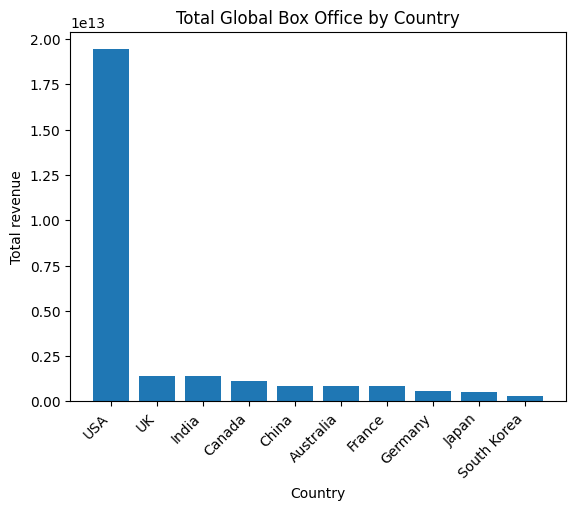

In [ ]:
sdf = (movies_df.groupBy("Country")
      .agg(F.sum("Global_BoxOfficeUSD").alias("total_global"))
      .orderBy(F.col("total_global"), ascending=False))

pdf = sdf.toPandas()

plt.figure()
plt.bar(pdf["Country"], pdf["total_global"])
plt.title("Total Global Box Office by Country")
plt.xlabel("Country")
plt.ylabel("Total revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

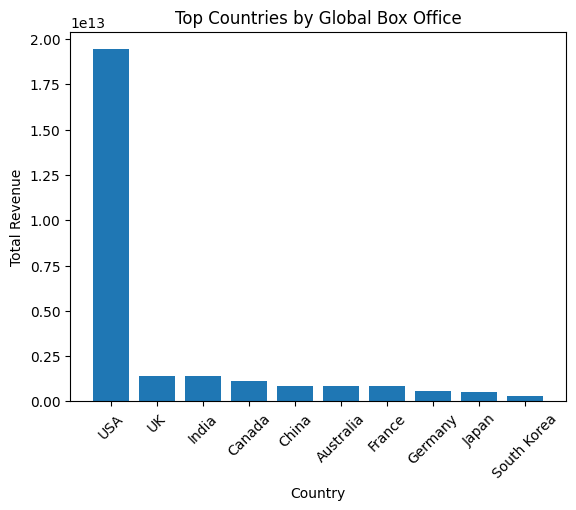

## Quetion 3: Which directors produce the highest rated movies after 2010?

In [22]:
movies_df.show(5)

+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|MovieID|               Title|      Genre|ReleaseYear|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|       Director|         LeadActor|ReleaseDate|
+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|      1|Might toward capital|     Comedy|       2003|  China|6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596| Kristina Moore|   Brian Mccormick| 2003-09-28|


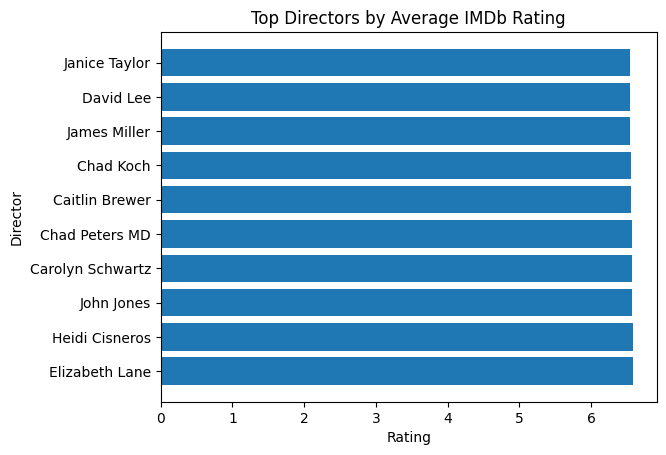

In [53]:
sdf = (movies_df.filter(F.col("ReleaseYear") > 2010)
       .groupBy("Director")
       .agg(F.avg("IMDbRating").alias("avg_imdb"))
       .orderBy(F.col("avg_imdb").desc())   
       .limit(10))                                

pdf = sdf.toPandas()

plt.figure()
plt.title("Top Directors by Average IMDb Rating")
plt.barh(pdf["Director"], pdf["avg_imdb"])
plt.xlabel("Rating")
plt.ylabel("Director")
plt.show()

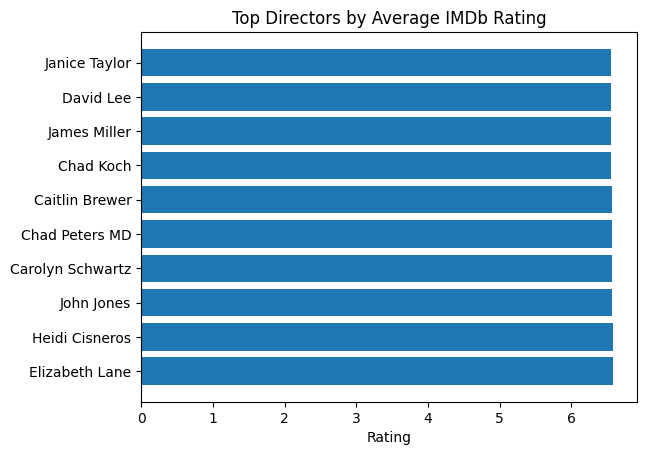

In [65]:
su._spark.stop()